In [ ]:
!pip install sentence-transformers seaborn matplotlib scikit-learn

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
sentences = [
    # Cricket (3)
    "The batsman scored a century in the final match.",
    "The bowler delivered a fast yorker to dismiss the player.",
    "The team won the match by chasing a huge target.",

    # Cooking (3)
    "The chef prepared a delicious pasta with fresh ingredients.",
    "Baking requires precise measurements of flour and sugar.",
    "The recipe includes spices and herbs for better flavor.",

    # Cybersecurity (4)
    "Strong passwords help protect against unauthorized access.",
    "Encryption ensures data is secure during transmission.",
    "Firewalls block malicious traffic from entering the network.",
    "Phishing attacks trick users into revealing sensitive information."
]

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)
print("Embeddings shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embeddings shape: (10, 384)


In [ ]:
similarity_matrix = cosine_similarity(embeddings)

print("Similarity Matrix Shape:", similarity_matrix.shape)

Similarity Matrix Shape: (10, 10)


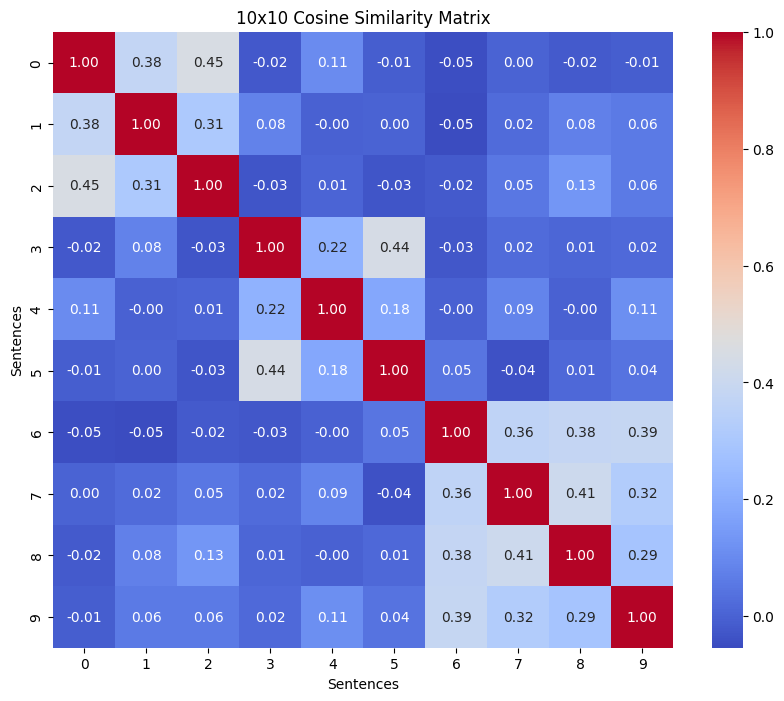

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("10x10 Cosine Similarity Matrix")
plt.xlabel("Sentences")
plt.ylabel("Sentences")
plt.show()

In [ ]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

In [ ]:
top_indices = np.argsort(similarities)[-2:][::-1]

print("Top 2 most similar sentences:\n")

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}")
    print()

Top 2 most similar sentences:

Sentence: The batsman scored a century in the final match.
Similarity Score: 0.5679

Sentence: The bowler delivered a fast yorker to dismiss the player.
Similarity Score: 0.5103

